In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

META_PATH = "/work/NLP-mini-project/datasets/fma/fma_raw/fma_metadata"

In [2]:
tracks = pd.read_csv(f"{META_PATH}/tracks.csv", index_col=0, header=[0, 1])
genres = pd.read_csv(f"{META_PATH}/genres.csv", index_col=0)

print("Tracks shape:", tracks.shape)
print("Tracks top-level columns:", tracks.columns.levels[0][:10])

Tracks shape: (106574, 52)
Tracks top-level columns: Index(['album', 'artist', 'set', 'track'], dtype='object')


In [4]:
tracks.columns = ["_".join(col).strip() for col in tracks.columns.values]
print("Flattened columns:", len(tracks.columns))
tracks.head()

echonest_path = f"{META_PATH}/echonest.csv"

try:
    echonest = pd.read_csv(echonest_path, index_col=0, header=[0, 1, 2])
    echonest.columns = ["_".join(col).strip() for col in echonest.columns.values]
    print("Loaded EchoNest:", echonest.shape)
    has_echonest = True
except:
    print("EchoNest missing — skipping.")
    has_echonest = False

Flattened columns: 52
Loaded EchoNest: (13129, 249)


In [6]:
df = tracks.copy()

# Add genre names
if "track_genre_top_id" in df.columns:
    df = df.merge(
        genres[["title", "top_level", "parent"]],
        left_on="track_genre_top_id",
        right_index=True,
        how="left",
        suffixes=("", "_genreinfo"),
    )

# Add EchoNest
if has_echonest:
    df = df.merge(echonest, left_index=True, right_index=True, how="left")

print("Merged metadata shape:", df.shape)
df.head()

cols_to_keep = [
    "track_title",
    "track_duration",
    "track_bit_rate",
    "track_genre_top",
    "track_genres",
    "track_genres_all",
    "set_split",
    "set_subset",
    "album_id",
    "artist_id",
    # EchoNest
    "echonest_audio_features_acousticness",
    "echonest_audio_features_danceability",
    "echonest_audio_features_energy",
    "echonest_audio_features_instrumentalness",
    "echonest_audio_features_liveness",
    "echonest_audio_features_speechiness",
    "echonest_audio_features_tempo",
    "echonest_audio_features_valence",
]

# Filter to existing columns
cols = [c for c in cols_to_keep if c in df.columns]
df = df[cols]

print("Shape after column selection:", df.shape)
df.head()

Merged metadata shape: (106574, 301)
Shape after column selection: (106574, 18)


,track_title,track_duration,track_bit_rate,track_genre_top,track_genres,track_genres_all,set_split,set_subset,album_id,artist_id,echonest_audio_features_acousticness,echonest_audio_features_danceability,echonest_audio_features_energy,echonest_audio_features_instrumentalness,echonest_audio_features_liveness,echonest_audio_features_speechiness,echonest_audio_features_tempo,echonest_audio_features_valence
track_id,,,,,,,,,,,,,,,,,,
2,Food,168,256000,Hip-Hop,[21],[21],training,small,1,1,0.416675,0.675894,0.634476,0.010628,0.177647,0.159310,165.922,0.576661
3,Electric Ave,237,256000,Hip-Hop,[21],[21],training,medium,1,1,0.374408,0.528643,0.817461,0.001851,0.105880,0.461818,126.957,0.269240
5,This World,206,256000,Hip-Hop,[21],[21],training,small,1,1,0.043567,0.745566,0.701470,0.000697,0.373143,0.124595,100.260,0.621661
10,Freeway,161,192000,Pop,[10],[10],training,small,6,6,0.951670,0.658179,0.924525,0.965427,0.115474,0.032985,111.562,0.963590
20,Spiritual Level,311,256000,NaN,"[76, 103]","[17, 10, 76, 103]",training,large,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
def is_empty_list(x):
    if isinstance(x, str):
        try:
            val = eval(x)
        except:
            return False
        return isinstance(val, list) and len(val) == 0
    return False


missing_summary = []

for col in df.columns:
    empty = (
        df[col].apply(is_empty_list)
        if col in ["track_genres", "track_genres_all"]
        else False
    )
    missing_percent = ((df[col].isna() | empty).mean()) * 100
    missing_summary.append((col, round(missing_percent, 2)))

missing_df = pd.DataFrame(missing_summary, columns=["column", "% missing"])
missing_df.sort_values(by="% missing", ascending=False)

,column,% missing
16,echonest_audio_features_tempo,87.68
17,echonest_audio_features_valence,87.68
13,echonest_audio_features_instrumentalness,87.68
12,echonest_audio_features_energy,87.68
15,echonest_audio_features_speechiness,87.68
14,echonest_audio_features_liveness,87.68
11,echonest_audio_features_danceability,87.68
10,echonest_audio_features_acousticness,87.68
3,track_genre_top,53.46
4,track_genres,2.09


In [8]:
children = {}
for gid, row in genres.iterrows():
    parent = int(row["parent"])
    children.setdefault(parent, []).append(gid)


def print_tree(node, level=0):
    indent = "   " * level
    title = genres.loc[node, "title"]
    print(f"{indent}- {title} ({node})")
    if node in children:
        for child in children[node]:
            if child != node:
                print_tree(child, level + 1)


print("Genre Hierarchy:\n")
for top in genres[genres["parent"] == 0].index:
    print_tree(top)

Genre Hierarchy:

- International (2)
   - Latin America (46)
      - Cumbia (502)
      - Salsa (808)
      - Tango (1060)
   - French (77)
   - Reggae - Dub (79)
      - Reggae - Dancehall (602)
   - Indian (86)
      - N. Indian Traditional (173)
      - South Indian Traditional (174)
      - Bollywood (175)
   - African (92)
      - Afrobeat (81)
      - North African (214)
   - Middle East (102)
      - Turkish (1032)
   - Polka (117)
   - Balkan (118)
   - Europe (130)
      - Romany (Gypsy) (524)
      - Spanish (619)
      - Klezmer (741)
      - Fado (1156)
   - Brazilian (171)
   - Asia-Far East (172)
   - Pacific (176)
   - Celtic (177)
   - Flamenco (232)
   - Latin (504)
- Blues (3)
   - Gospel (567)
- Jazz (4)
   - Jazz: Vocal (37)
   - Free-Jazz (74)
   - Jazz: Out (97)
   - Be-Bop (178)
   - Big Band/Swing (179)
   - Modern Jazz (906)
- Classical (5)
   - 20th Century Classical (187)
   - Composed Music (322)
   - Opera (441)
   - Chamber Music (442)
   - Choral Music (

In [11]:
top_ids = {2, 3, 4, 5, 8, 9, 10, 12, 13, 14, 15, 17, 20, 21, 38, 1235}


def extract_top_levels(x):
    if isinstance(x, str):
        ids = eval(x)  # convert "[21, 103]" → [21, 103]
    else:
        ids = x
    return [g for g in ids if g in top_ids]


df["top_genres"] = df["track_genres_all"].apply(extract_top_levels)
df["num_top"] = df["top_genres"].apply(len)

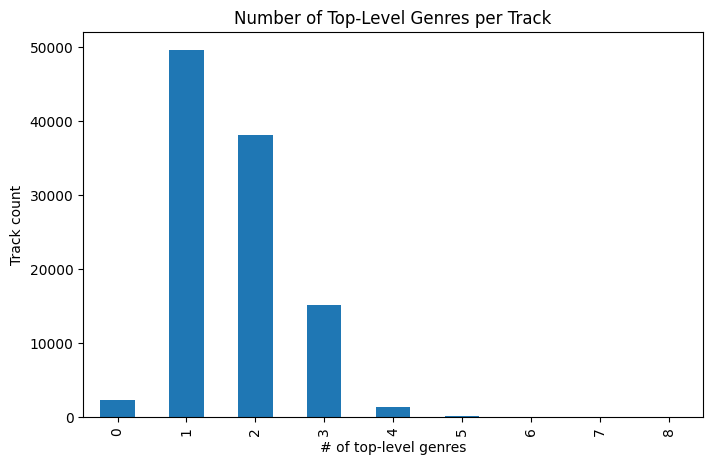

In [12]:
df["num_top"].value_counts().sort_index()

df["num_top"].value_counts().sort_index().plot(kind="bar", figsize=(8, 5))
plt.title("Number of Top-Level Genres per Track")
plt.xlabel("# of top-level genres")
plt.ylabel("Track count")
plt.show()

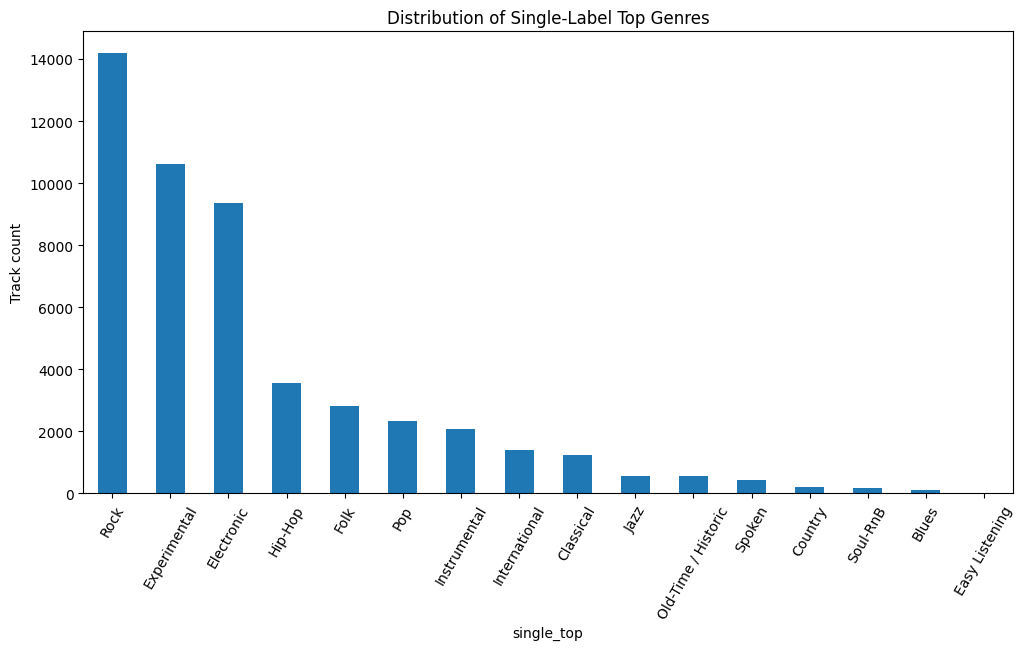

In [13]:
df_single = df[df["num_top"] == 1].copy()
df_single["single_top"] = df_single["top_genres"].apply(lambda x: x[0])

label_counts = df_single["single_top"].value_counts()

# Map genre IDs → names
id_to_title = genres["title"].to_dict()
label_counts_named = label_counts.rename(index=id_to_title)

label_counts_named.plot(kind="bar", figsize=(12, 6))
plt.xticks(rotation=60)
plt.title("Distribution of Single-Label Top Genres")
plt.ylabel("Track count")
plt.show()

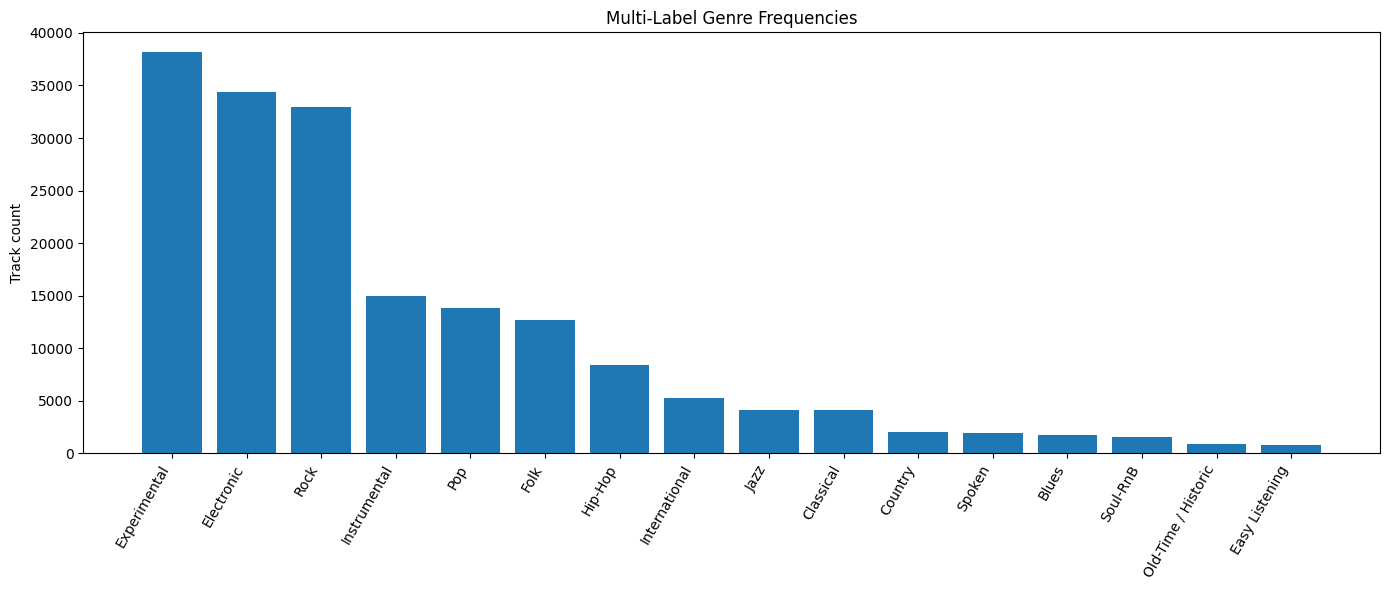

Label cardinality (avg labels per track): 1.666
Label density: 0.10414


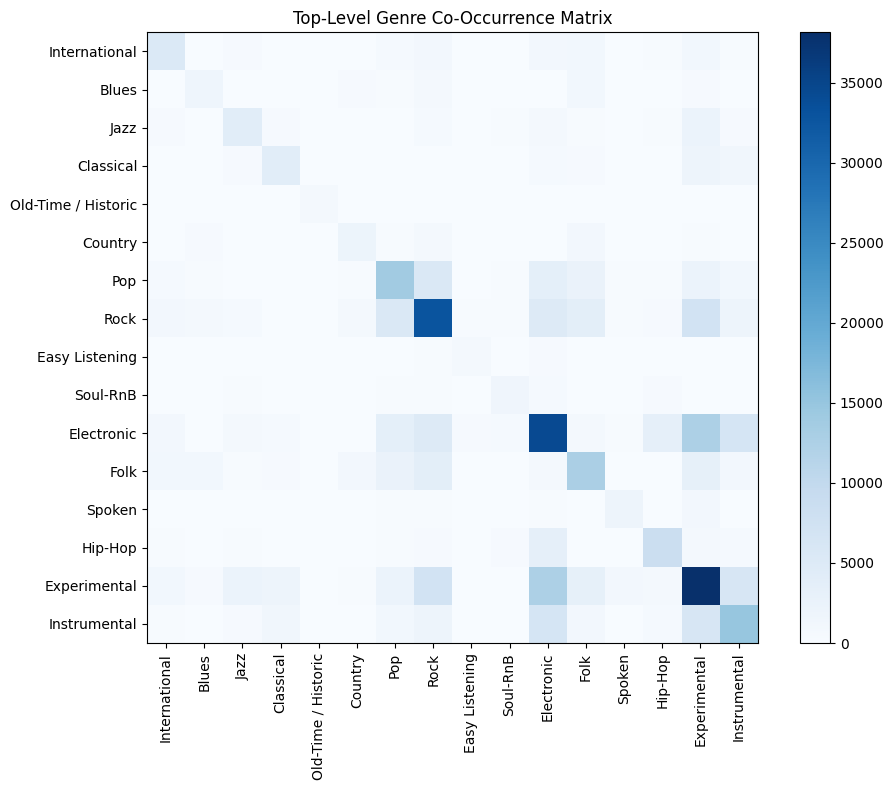

In [16]:
# Sort all top-level genre IDs to ensure consistent ordering
label_list = sorted(top_ids)

# Map genre IDs to human-readable names
id_to_title = genres["title"].to_dict()

# Create binary indicator columns for each top-level genre
df_ml = df.copy()
for g in label_list:
    df_ml[f"label_{g}"] = df_ml["top_genres"].apply(lambda lst: int(g in lst))

# Compute per-genre frequency across all tracks
label_freq = {g: df_ml[f"label_{g}"].sum() for g in label_list}
label_freq_named = pd.Series(
    {id_to_title[g]: label_freq[g] for g in label_list}
).sort_values(ascending=False)

# Plot per-genre frequency
plt.figure(figsize=(14, 6))
plt.bar(label_freq_named.index, label_freq_named.values)
plt.xticks(rotation=60, ha="right")
plt.title("Multi-Label Genre Frequencies")
plt.ylabel("Track count")
plt.tight_layout()
plt.show()

# Compute label cardinality: average number of top-level genres per track
df_ml["num_labels"] = df_ml["top_genres"].apply(len)
label_cardinality = df_ml["num_labels"].mean()
print("Label cardinality (avg labels per track):", round(label_cardinality, 3))

# Compute label density: cardinality divided by total number of genres
num_labels = len(label_list)
label_density = label_cardinality / num_labels
print("Label density:", round(label_density, 5))

# Compute co-occurrence matrix for all top-level genres
co_matrix = np.zeros((num_labels, num_labels))
for lst in df_ml["top_genres"]:
    for g1 in lst:
        for g2 in lst:
            i = label_list.index(g1)
            j = label_list.index(g2)
            co_matrix[i, j] += 1

# Plot co-occurrence heatmap
plt.figure(figsize=(10, 8))
plt.imshow(co_matrix, cmap="Blues")
plt.xticks(range(num_labels), [id_to_title[g] for g in label_list], rotation=90)
plt.yticks(range(num_labels), [id_to_title[g] for g in label_list])
plt.colorbar()
plt.title("Top-Level Genre Co-Occurrence Matrix")
plt.tight_layout()
plt.show()


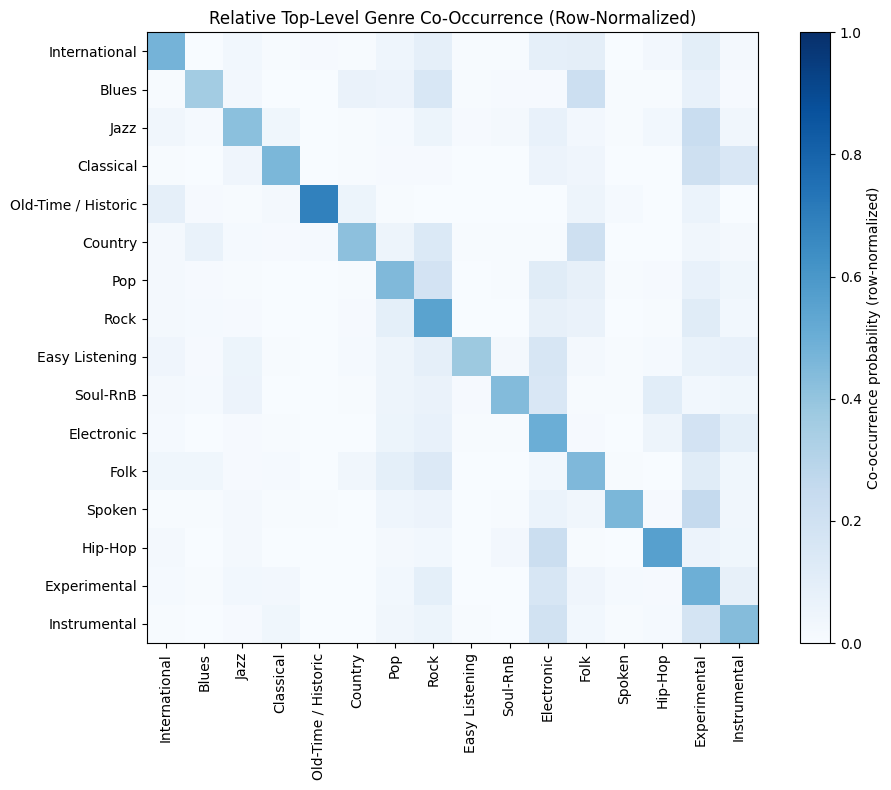

In [17]:
num_labels = len(label_list)

# Recompute co-occurrence matrix
co_matrix = np.zeros((num_labels, num_labels))

for lst in df_ml["top_genres"]:
    for g1 in lst:
        for g2 in lst:
            i = label_list.index(g1)
            j = label_list.index(g2)
            co_matrix[i, j] += 1

# Row-normalize: divide each row by its row sum
row_sums = co_matrix.sum(axis=1, keepdims=True)
co_matrix_rel = co_matrix / row_sums  # gives values in [0,1]

# Replace NaN rows (genres with 0 samples) with 0
co_matrix_rel = np.nan_to_num(co_matrix_rel)

# Plot relative co-occurrence matrix
plt.figure(figsize=(10, 8))
plt.imshow(co_matrix_rel, cmap="Blues", vmin=0, vmax=1)

plt.xticks(range(num_labels), [id_to_title[g] for g in label_list], rotation=90)
plt.yticks(range(num_labels), [id_to_title[g] for g in label_list])
plt.colorbar(label="Co-occurrence probability (row-normalized)")

plt.title("Relative Top-Level Genre Co-Occurrence (Row-Normalized)")
plt.tight_layout()
plt.show()


In [18]:
ratio = label_freq_named.max() / label_freq_named.min()
print("Imbalance ratio:", ratio)

Imbalance ratio: 52.26575342465753


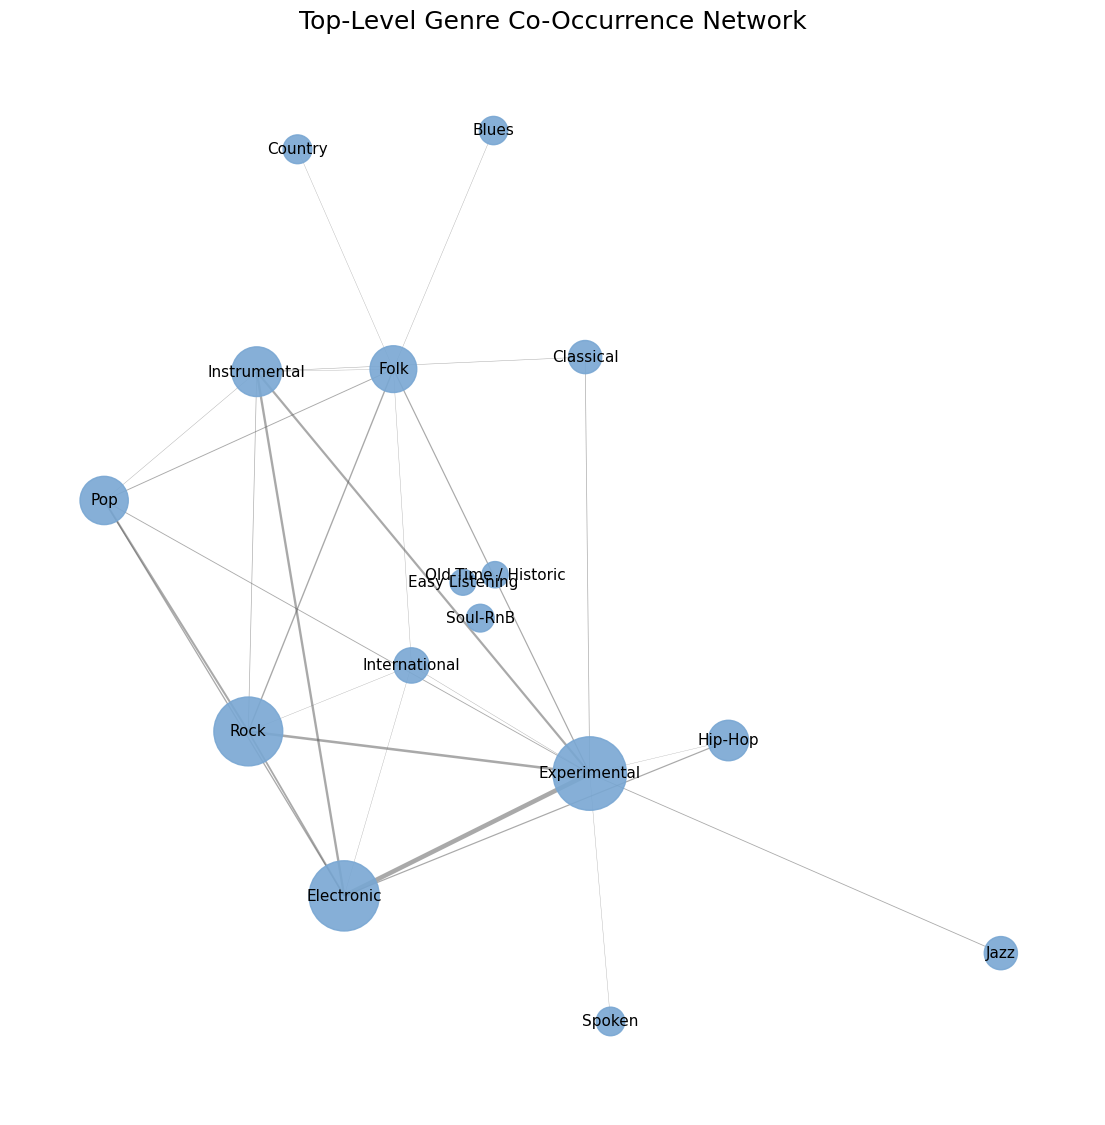

In [25]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: genre list ---
all_genres = sorted(top_ids)
id_to_title = genres["title"].to_dict()

# --- Step 2: compute co-occurrence ---
n = len(all_genres)
co = np.zeros((n, n), dtype=int)

for lst in df["top_genres"]:
    for g1 in lst:
        for g2 in lst:
            i = all_genres.index(g1)
            j = all_genres.index(g2)
            co[i, j] += 1

# --- Step 3: build graph ---
G = nx.Graph()

# node sizes
genre_counts = {
    g: df["top_genres"].apply(lambda x: g in x).sum() 
    for g in all_genres
}

# normalize node sizes for plotting
max_count = max(genre_counts.values())
node_sizes = {
    id_to_title[g]: (genre_counts[g] / max_count) * 2500 + 300  # 300–2800 range
    for g in all_genres
}

# add nodes
for name, size in node_sizes.items():
    G.add_node(name, size=size)

# add edges with threshold
threshold = 800
for i in range(n):
    for j in range(i+1, n):
        if co[i, j] > threshold:
            G.add_edge(
                id_to_title[all_genres[i]],
                id_to_title[all_genres[j]],
                weight=co[i, j]
            )

# --- Step 4: Stable layout: Kamada-Kawai ---
pos = nx.kamada_kawai_layout(G)   # very stable, no explosions

# --- Step 5: Scale edge widths ---
edge_widths = [
    d['weight'] / max(co.flatten()) * 10
    for (_, _, d) in G.edges(data=True)
]

# --- Step 6: Draw graph ---
plt.figure(figsize=(14, 14))

nx.draw_networkx_nodes(
    G, pos,
    node_size=[G.nodes[n]['size'] for n in G.nodes()],
    node_color="#79a7d3", alpha=0.9
)

nx.draw_networkx_edges(
    G, pos, 
    width=edge_widths, 
    edge_color="#555555", 
    alpha=0.5
)

nx.draw_networkx_labels(G, pos, font_size=11)

plt.title("Top-Level Genre Co-Occurrence Network", fontsize=18)
plt.axis("off")
plt.show()
